In [1]:
# Environment Setup
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization,
    MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
IMG_SIZE = (48, 48)          
NUM_CLASSES = 43
BATCH_SIZE = 64
EPOCHS = 50

In [4]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")
meta = pd.read_csv("Meta.csv")

print(f"Train samples: {len(train)} | Test samples: {len(test)} | Classes: {len(meta)}")

CLASS_NAMES = {row['ClassId']: f"Sign_{row['SignId']}" for _, row in meta.iterrows()}

Train samples: 39209 | Test samples: 12630 | Classes: 43


In [5]:
def preprocess_image(img_path, roi_coords=None, target_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if roi_coords is not None:
        x1, y1, x2, y2 = roi_coords
        h, w = img.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 > x1 and y2 > y1:
            img = img[y1:y2, x1:x2]

    img = cv2.resize(img, target_size)
    
    return img.astype(np.float32)  



In [6]:
def load_dataset(df):
    images, labels = [], []
    for _, row in df.iterrows():
        roi = row[['Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2']].values
        img = preprocess_image(row['Path'], roi)
        if img is not None:
            images.append(img)
            labels.append(row['ClassId'])
    return np.array(images), np.array(labels)


In [7]:
X_train, y_train = load_dataset(train)
X_test,  y_test  = load_dataset(test)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Pixel range check — min: {X_train.min()}, max: {X_train.max()}")

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

X_train shape: (39209, 48, 48, 3) | X_test shape: (12630, 48, 48, 3)
Pixel range check — min: 0.0, max: 255.0


In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_cat,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

In [9]:
datagen = ImageDataGenerator(
    rescale=1./255,            
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=False,     
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
def build_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',                      
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(X_tr.shape[1:], NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,480,779 (5.65 MB)

 Trainable params: 1,479,371 (5.64 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,               
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               
    patience=3,
    min_lr=1e-5,
    verbose=1
)

In [12]:
history = model.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 367s 633ms/step - accuracy: 0.6675 - loss: 1.1843 - val_accuracy: 0.9521 - val_loss: 0.1632 - learning_rate: 0.0010
Epoch 2/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 331s 600ms/step - accuracy: 0.9504 - loss: 0.1733 - val_accuracy: 0.9962 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 3/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 330s 597ms/step - accuracy: 0.9767 - loss: 0.0852 - val_accuracy: 0.9962 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 4/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 327s 593ms/step - accuracy: 0.9841 - loss: 0.0564 - val_accuracy: 0.9982 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 5/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 328s 594ms/step - accuracy: 0.9862 - loss: 0.0465 - val_accuracy: 0.9980 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 6/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 323s 586ms/step - accuracy: 0.9870 - loss: 0.0437 - val_accuracy: 0.9977 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 7/50
552/552 ━━━━━━━━━━━━━━━━━━━━ 340s 616ms/step - accura

In [13]:
X_test_norm = X_test / 255.0
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\n✓ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


✓ Test Accuracy: 0.9933 | Test Loss: 0.0307


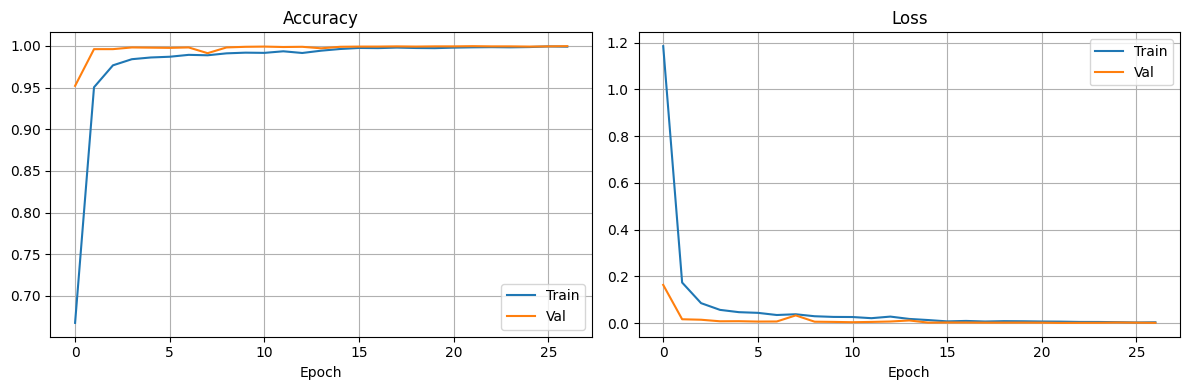

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step


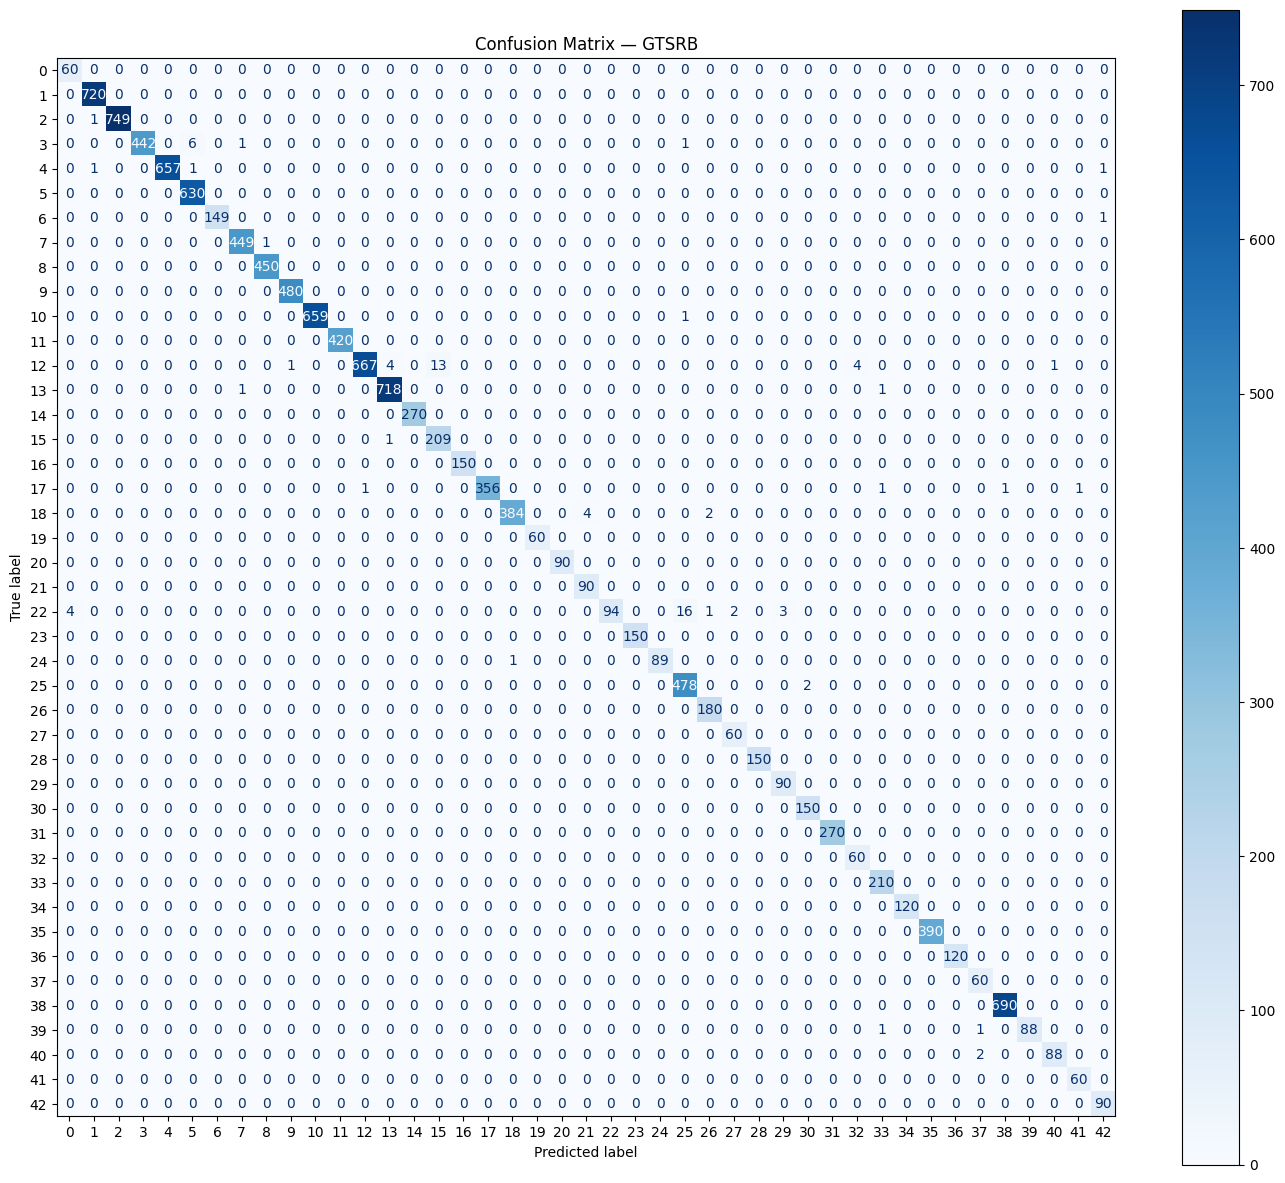

In [15]:
y_pred = np.argmax(model.predict(X_test_norm), axis=1)

fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix — GTSRB")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [16]:
model.save("model.h5")
print("Model saved as model.h5")

Model saved as model.h5
